<a href="https://colab.research.google.com/github/NicolasZarateC/Analitica-de-Negocios/blob/main/Reto_Modelos_Neuronales_Zarate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalar Paquetes

In [ ]:
!pip install tensorflow

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nxl='/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Bases de Datos/6. SolicitantesCrédito(USD) (1).xlsx'
XDB=pd.read_excel(nxl,sheet_name=1)
XDB=XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos', 'Egresos' ,'Monto (EAD)','Plazo','Cuota (COP)','Score']]

#Variables de Entrada y Salida
XD=np.array(XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos', 'Egresos' ,'Monto (EAD)','Plazo','Cuota (COP)']]); XDn=XD/np.max(XD,axis=0)
yd=np.array(XDB[['Score']]) ; ydn=yd/np.max(yd,axis=0)

print('Los datos de entrada normalizados son:\n',XDn)

Los datos de entrada normalizados son:
 [[0.52054795 0.14285714 0.         ... 0.15349289 0.8        0.02045638]
 [0.69863014 0.85714286 0.2        ... 0.03435935 0.6        0.00563566]
 [0.50684932 0.28571429 0.         ... 0.06982299 0.6        0.01145244]
 ...
 [0.52054795 0.         0.         ... 0.14598111 0.6        0.02394398]
 [0.5890411  0.14285714 0.4        ... 0.07497965 0.6        0.01229825]
 [0.50684932 0.14285714 0.4        ... 0.246751   0.6        0.04047237]]


Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0128
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0110
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0089
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0064
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0053
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0039
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0021
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0020
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0

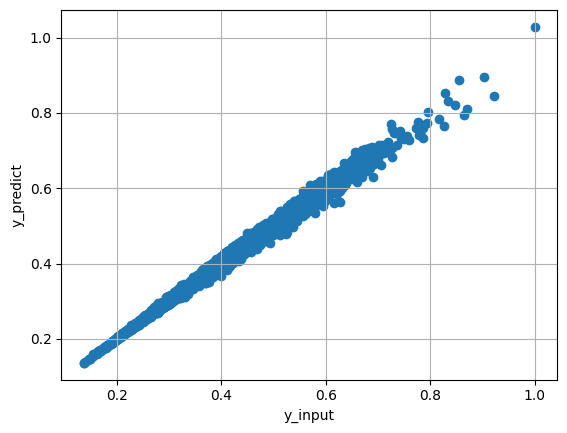

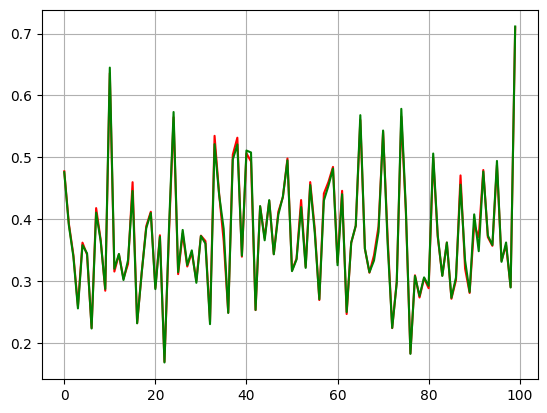

La correlacion de los datos es:
           0         1
0  1.000000  0.996786
1  0.996786  1.000000
Las conexiones son:
 [array([[ 0.16428448],
       [ 0.03413575],
       [ 0.02628169],
       [ 0.16387379],
       [ 0.45928502],
       [-0.09115124],
       [ 0.08100104],
       [ 0.15686518],
       [ 0.31830052]], dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
El score estimado es:
 [[733.40112336]]


In [ ]:
adaline=tf.keras.models.Sequential([
    tf.keras.layers.Dense(1,input_shape=(9,),activation='relu',use_bias=False)])
adaline.load_weights("/content/pesos_adaline_L.weights.h5")
adaline.compile(optimizer='sgd',loss='mse')
history=adaline.fit(XDn,ydn,epochs=100) #Recoora la tabla de datos de 100
ydp=adaline.predict(XDn) #Pronostico al final del aprendizaje

plt.figure()
plt.scatter(ydn,ydp)
plt.grid()
plt.xlabel('y_input')
plt.ylabel('y_predict')
plt.show()

plt.figure()
plt.plot(ydn[0:100,],color='red')
plt.plot(ydp[0:100,],color='green')
plt.grid()
plt.show()

#Determinamos la correlacion
df=pd.DataFrame(np.column_stack((ydn,ydp)))
print('La correlacion de los datos es:\n',df.corr())

#Las conexiones nerviosas son:
w=adaline.get_weights()
print('Las conexiones son:\n',w)

#Para evaluar un solicitante d ecredito con las siguientes variables
Xsc=[[45,1,0,4,2000,1000,1200,24,60]] ; Xscn=Xsc/np.max(XD,axis=0)
ydpsc=adaline.predict(Xscn)
print('El score estimado es:\n',ydpsc*np.max(yd,axis=0))

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

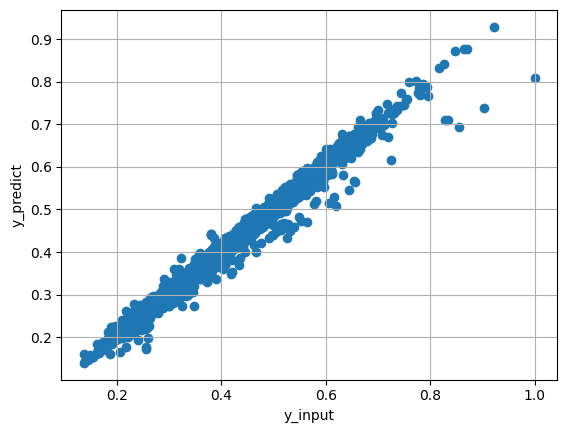

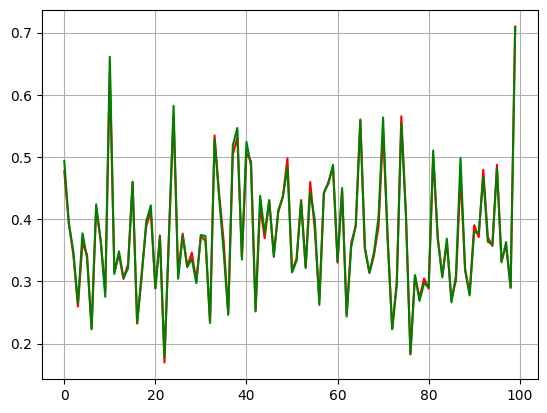

La correlacion de los datos es:
           0         1
0  1.000000  0.993164
1  0.993164  1.000000


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,0.201796,0.299236,-0.170855,0.297845,0.10056,0.300169,0.280464,0.291071,-0.202699


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
El score estimado es:
 [[634.81269812]]


np.float64(6057.139480471611)

In [ ]:
madaline=tf.keras.models.Sequential([
    tf.keras.layers.Dense(10,input_shape=(9,),activation='relu',use_bias=False), #Capa 1_ 10 regresiones
    tf.keras.layers.Dense(1,activation='relu',use_bias=False)]) #Capa 2: Nucleo - Salida
madaline.load_weights("/content/pesos_madaline_L.weights.h5")
madaline.compile(optimizer='sgd',loss='mse') #sgd: Solve descend gradient
                                              #mse mena square error - quiero que se acero
                                              #Recorrer 100 veces la tabla de datos
                                              #Pronostico al final del aprendizaje
history=madaline.fit(XDn,ydn,epochs=100)
ydp=madaline.predict(XDn)

#Grafica de correlacion
plt.figure()
plt.scatter(ydn,ydp)
plt.grid()
plt.xlabel('y_input')
plt.ylabel('y_predict')
plt.show()

#Grafica  de pronostico
plt.figure()
plt.plot(ydn[0:100,],color='red')
plt.plot(ydp[0:100,],color='green')
plt.grid()
plt.show()

#Determinamos la correlacion
df=pd.DataFrame(np.column_stack((ydn,ydp)))
print('La correlacion de los datos es:\n',df.corr())

#Obteenemos las conexiones de la red
#W=madaline.get_weights()[0]
#print('Las conexiones son:\n',W)

#Obteenemos las conexiones de la red / como dispersan las conexiones nerviosas
WC=madaline.get_weights() #estas son las capas :
W=WC[0]; C=WC[1] #Capa 0: 4 a 10 ; Capa 1: 1 a 10 Salida . Conexiones nerviosas (10 regresiones)
a=W@C # Producto entre las conexiones como Ws pasane entre los C
      #a son las efectos independientes de las variabels sobre salida
      #Cuales es mas imporante que otro, y cual tiene un efecto positivo o negativo sobre la salida
df2=pd.DataFrame(a.T)
df2.columns=['Edad','Hijos','Perscargo','Estrato','Ingresos', 'Egresos' ,'Monto (EAD)','Plazo','Cuota (COP)']
display(df2) #Muestra el peso que tiene cada variable sobre la salida

#Como evaluar un nuevo solicitante de credito
Xsc=[[45,1,0,4,2000,1000,1200,24,60]] ; Xscn=Xsc/np.max(XD,axis=0)
ydpsc=madaline.predict(Xscn)
print('El score estimado es:\n',ydpsc*np.max(yd,axis=0))

np.sum(a@Xsc)

**Analisis**

En este código usamos las 9 variables de la base de datos: Edad, Hijos, Personas a Cargo, Estrato, Ingresos, Egresos, Monto, Plazo y Cuota respecto a la variable Score para analizar el credito con dos modelos de redes neuronales ADALINE (Adaptive Linear Neuron) y MADALINE (Multiple Adaptive Linear Neuron).

Comparando los resultados de los dos modelos, vemos que las dos graficas se parecen y esto es debido a los niveles de correlación porque estan cerca al 100%.

Además, vemos que algunas correlaciones salen positivas y negativas en los dos modelos.Por ejemplo en el de ADALINE vemos que el único negativo es el de egresos y en el de MADALINE son personas a cargo y cuota. Estas variables que tienen esta coefficiente negativa tiende a hacer la variable score más bajita.

Al estimar cual seria el score de una persona con Edad 45, Hijos 1, sin Personas a Cargo 0, Estrato 4, Ingresos 2000, Egresos 1000, Monto 1200, Plazo 24, Cuota 60 COP vemos que el modelo ADALINE nos arroja un número más alto que el MADALINE ya que tiene menos conexiones neuronales al dar el analisis con más capas y de forma más precisa gracias a esto.

